# Speed Dating - data analysis

## **1. Objectifs et méthode**

**Contexte et méthode**

Contexte du projet :
* Baisse du nombre de correspondance sur application de rencontre

Objectif du projet :
* Comprendre de qui motive l'intérêt des utilisateurs à valider une correspondance

**Méthodologie du projet**

Collecte des données 
* Période : 2002 - 2004
* Durée du speed dating : 4 min
* Chaque participant rencontre une personne du sexe opposé
* Variantes : les sessions 5, 12, 13, 14, 18, 19, 20, 21 ont fait l'objet de variations (objets à apporter, quotas de "oui" dans les match,...)

Evaluation du speed dating
* A l'issue de la rencontre, les participans indiquent s'ils souhaitent revoir leur partenaire
* Evaluation du partenaires en 3 temps : à l'issue de la rencontre, le jour suivant la rencontre, 3-4 semaines après la rencontre
* Notation du partenaire : attrait, sincérité, intelligence, plaisir, ambition, centre d'intérêts communs

Informations participants
* Données démographiques, habitudes amoureuses, perception de soi selon ses principaux attributs, croyances sur ce que les autres apprécient chez un partenaire, informations sur le mode de vie

Constitution du dataset
* A chaque ligne correspond 1 speed dating
* Les participants sont présents autant de fois qu'ils réalisent de speed dating

**Questions auxquelles l'exploration doit répondre**
* Quels sont les attributs les moins désirables chez un partenaire masculin ? 
* Est-ce différent chez les partenaires féminines ?
* Est-ce que l'importance de l'attractivité se vérifie dans le choix final ?

**Résumé**
* 8378 entretiens réalisés auprès de 551 participants
* 16% des speed dating réalisés ont trouvé un 'match' (soit, 15% des participants)
* les critères recherchés ne sont pas nécessairement les critères de sélection pour valider une décision


## **2. Imports, configuration, chargement, nettoyage initial**

In [65]:
# Import des librairies
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Afficher toutes les colonnes sans tronquage
pd.set_option("display.max_columns", None)

In [66]:
# Lecture du dataset
df = pd.read_csv("Speed+Dating+Data.csv", encoding="ISO-8859-1")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


In [67]:
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,1,11.0,0,0.14,0,27.0,2.0,35.0,20.0,20.0,20.0,0.0,5.0,0,6.0,8.0,8.0,8.0,8.0,6.0,7.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,6.0,9.0,7.0,7.0,6.0,5.0,7.0,6.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,2,12.0,0,0.54,0,22.0,2.0,60.0,0.0,0.0,40.0,0.0,0.0,0,7.0,8.0,10.0,7.0,7.0,5.0,8.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,7.0,8.0,7.0,8.0,5.0,6.0,7.0,5.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,3,13.0,1,0.16,1,22.0,4.0,19.0,18.0,19.0,18.0,14.0,12.0,1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,4,14.0,1,0.61,0,23.0,2.0,30.0,5.0,15.0,40.0,5.0,5.0,1,7.0,8.0,9.0,8.0,9

In [68]:
df.describe(include="all")

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,8378.000000,8368.000000,8378.000000,8220.000000,8378.000000,8274.000000,8305.000000,8289.000000,8289.000000,8289.000000,8280.000000,8271.000000,8249.000000,8378.000000,8166.000000,8091.000000,8072.000000,8018.000000,7656.000000,7302.000000,8128.000000,8060.000000,7993.000000,8283.000000,8315,8296.000000,4914,3133,3583,8315.000000,8299.000000,8299.000000,8299,7314,4279,8299.000000,8281.000000,8299.000000,8289,8240.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8277.000000,1800.000000,8299.000000,8299.000000,8299.000000,8289.000000,8279.000000,8257.000000,6489.000000,6489.000000,6489.000000,6489.000000,6489.000000,6467.000000,8299.000000,8299.000000,8299.000000,8299.000000,8289.000000,8289.000000,8273.000000,8273.000000,8273.000000,8273.000000,8273.000000,4906.000000,4906.000000,4906.000000,4906.000000,4906.000000,8378.000000,8176.000000,8101.000000,8082.000000,8028.000000,7666.000000,7311.000000,8138.000000,8069.000000,8003.000000,7205.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,7463.000000,7463.000000,7433.000000,1984.000000,1955.000000,1984.000000,1984.000000,1955.000000,1974.000000,7445.000000,7463.000000,7463.000000,7463.000000,7463.000000,7463.000000,5775.000000,5775.000000,5775.000000,5775.000000,5775.000000,5775.000000,5775.000000,5775.00000,5775.000000,5775.000000,5775.000000,5775.000000,7463.000000,7463.000000,7463.000000,7463.000000,7463.000000,4377.000000,4377.000000,4377.000000,4377.000000,4377.000000,3974.000000,3974.000000,3974.000000,1496.000000,668.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2959.000000,2016.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,259,NaN,241,68,115,NaN,NaN,NaN,269,409,261,NaN,NaN,NaN,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [69]:
# Nettoyage initial - identification des valeurs manquantes
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values_percentage = (missing_values / len(df)) * 100
print(missing_values_percentage.round().nlargest(10))

# Identification des variables ayant +40% de valeurs manquantes dans le dataset
cols_del = missing_values_percentage[missing_values_percentage >= 40].index
cols_del

num_in_3    92.0
numdat_3    82.0
expnum      79.0
sinc7_2     77.0
amb7_2      77.0
shar7_2     76.0
attr7_2     76.0
intel7_2    76.0
fun7_2      76.0
amb5_3      76.0
dtype: float64


Index(['num_in_3', 'numdat_3', 'expnum', 'sinc7_2', 'amb7_2', 'shar7_2',
       'attr7_2', 'intel7_2', 'fun7_2', 'amb5_3', 'attr7_3', 'sinc7_3',
       'intel7_3', 'fun7_3', 'amb7_3', 'shar7_3', 'shar2_3', 'attr5_3',
       'sinc5_3', 'intel5_3', 'fun5_3', 'attr4_3', 'sinc4_3', 'intel4_3',
       'fun4_3', 'amb4_3', 'shar4_3', 'attr2_3', 'sinc2_3', 'fun2_3',
       'intel2_3', 'amb2_3', 'mn_sat', 'tuition', 'you_call', 'shar1_3',
       'date_3', 'attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3',
       'attr3_3', 'sinc3_3', 'intel3_3', 'fun3_3', 'amb3_3', 'them_cal',
       'fun3_s', 'intel3_s', 'sinc3_s', 'amb3_s', 'attr3_s', 'fun1_s',
       'intel1_s', 'amb1_s', 'attr1_s', 'sinc1_s', 'shar1_s', 'income',
       'attr5_2', 'sinc5_2', 'fun5_2', 'intel5_2', 'amb5_2', 'amb5_1',
       'fun5_1', 'intel5_1', 'sinc5_1', 'attr5_1', 'undergra'],
      dtype='object')

* Les variables les moins renseignées sont majoritairement issues des notes attribuées par les participants à leur partenaires. 
* Les informations demandées 3-4 semaines après le date sont moins renseignés que les autres.

Hypothèses :
* perte intérêt pour partciper à l'expérience une fois le speed dating passé
* redondance des questions
* pas de changement dans les réponses à apporter par rapport à celles répondues précédemment

Conservation de ces variables dans le jeu de données car non impactantes pour l'analyse par la suite

## **3. Analyse du dataset**
1. Nombre de match
2. Description des participantes
3. Description des variables de décision


### **3.1 Nombre de match**

In [70]:
# Identification du nombre de 'match'
df["match"].value_counts(normalize=True).mul(100).round(2)

match
0    83.53
1    16.47
Name: proportion, dtype: float64

* 83.5% des speeds dating n'ont pas débouché sur un match
* 16.5% des speeds dating ont débouché sur un match



### **3.2 Description des participants**

Chaque particpants participe plusieurs fois dans la même session, mais toutes les sessions n'ont pas le même nombre de participants. Pour éviter les biais, il est crée un sous tableau participants afin d'identifier chaque unique participant.

In [71]:
# Définition du tableau participants
df_participants = (
    df[
        [
            "iid",
            "wave",
            "id",
            "gender",
            "age",
            "field",
            "field_cd",
            "race",
            "imprace",
            "imprelig",
            "from",
            "zipcode",
            "goal",
            "date",
            "go_out",
            "career",
            "career_c",
            "sports",
            "tvsports",
            "exercise",
            "dining",
            "museums",
            "art",
            "hiking",
            "gaming",
            "clubbing",
            "reading",
            "tv",
            "theater",
            "movies",
            "concerts",
            "music",
            "shopping",
            "yoga",
            "exphappy",
            "match_es",
            "match",
        ]
    ]
    .drop_duplicates("iid")
    .copy()
)

# Identification du nombre de 'match'
df_participants["match"].value_counts(normalize=True).mul(100).round(2)

match
0    84.94
1    15.06
Name: proportion, dtype: float64

85% des participants n'ont pas 'matché' durant l'expérience
15% des participants ont 'matché' durant l'expérience

In [72]:
# Renommer les étiquettes pour meilleure lecture
df_participants["gender"] = df_participants.gender.map(
    {0: "Female", 1: "Male"}
).fillna(df_participants.gender)

# Participants par genre
gender_count = df_participants.gender.value_counts(dropna=False)
gender_percent = (
    df_participants.gender.value_counts(normalize=True).mul(100).round(2)
)

# Editer nouveau tableau
gender_summary = pd.DataFrame(
    {"Nombre de participants": gender_count, "Pourcentage (%)": gender_percent}
)

# Trier par nombre de participants
gender_summary = gender_summary.sort_values(
    # by=désigne par quel variable on tri
    by="Nombre de participants",
    ascending=False,
)

display(gender_summary)

,Nombre de participants,Pourcentage (%)
gender,,
Male,277,50.27
Female,274,49.73


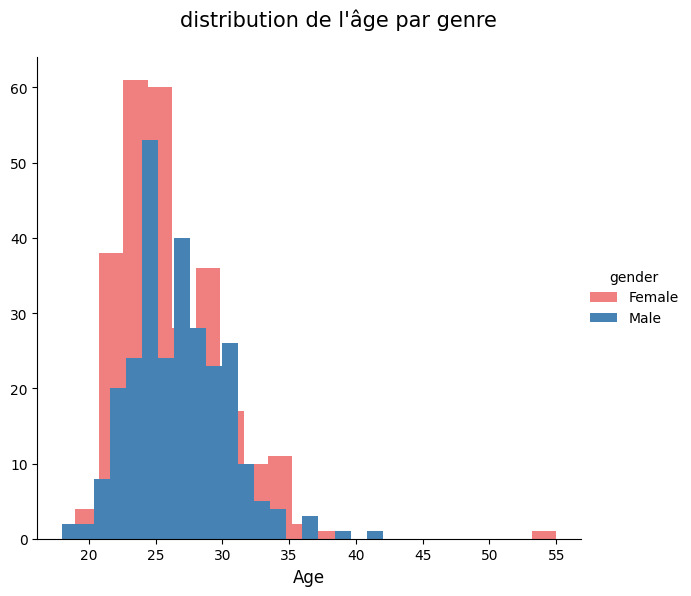

In [ ]:
# Distribution de l'âge des participants par genre
PALETTE = {"Male": "steelblue", "Female": "lightcoral"}
age_gender = sns.FacetGrid(
    df_participants, hue="gender", height=6, palette=PALETTE
)
age_gender.map(plt.hist, "age", alpha=1, bins=20)
age_gender.set_xlabels("Age", fontsize=12)

plt.subplots_adjust(top=0.9)
age_gender.figure.suptitle("Distribution de l'âge par genre", fontsize=15)
age_gender.add_legend()

In [74]:
# Eléments descriptifs sur l'âge en fonction du genre des participants
df_participants[["gender", "age"]].groupby("gender").agg(
    ["mean", "median", "min", "max", "count"]
).round(2)

age                         
         mean median   min   max count
gender                                
Female  26.13   26.0  19.0  55.0   269
Male    26.59   27.0  18.0  42.0   274

Parmi les 551 participants,
* Equilibre hommes/femmes
* Moyenne d'âge de 26 ans pour les femmes et les hommes

--> plus de la moitié des membres de Tinder sont âgés de 18 à 25 ans

--> appétence des jeunes pour l'utilisation des réseaux sociaux



In [75]:
# Domaine d'étude des participants
df_participants["field_cd"] = df_participants.field_cd.map(
    {
        1: "Law",
        2: "Math",
        3: "Social Science, Psychologist",
        4: "Medical Science, Pharmaceuticals, and Bio Tech ",
        5: "Engineering",
        6: "English/Creative Writing/ Journalism ",
        7: "History/Religion/Philosophy ",
        8: "Business/Econ/Finance",
        9: "Education, Academia",
        10: "Biological Sciences/Chemistry/Physics",
        11: "Social Work ",
        12: "Undergrad/undecided",
        13: "Political Science/International Affairs",
        14: "Film",
        15: "Fine Arts/Arts Administration",
        16: "Languages",
        17: "Architecture",
        18: "Other",
    }
).fillna(df_participants.field_cd)

print(df_participants.field_cd.value_counts(dropna=False))
df_participants.field_cd.value_counts(normalize=True).mul(100).round(2)

field_cd
Business/Econ/Finance                              130
Biological Sciences/Chemistry/Physics               61
Engineering                                         56
Law                                                 48
Political Science/International Affairs             46
Social Science, Psychologist                        46
Education, Academia                                 40
Social Work                                         30
English/Creative Writing/ Journalism                21
History/Religion/Philosophy                         17
Math                                                14
Fine Arts/Arts Administration                       11
Medical Science, Pharmaceuticals, and Bio Tech       9
NaN                                                  7
Film                                                 7
Other                                                3
Languages                                            3
Architecture                                         1
U

field_cd
Business/Econ/Finance                              23.90
Biological Sciences/Chemistry/Physics              11.21
Engineering                                        10.29
Law                                                 8.82
Political Science/International Affairs             8.46
Social Science, Psychologist                        8.46
Education, Academia                                 7.35
Social Work                                         5.51
English/Creative Writing/ Journalism                3.86
History/Religion/Philosophy                         3.12
Math                                                2.57
Fine Arts/Arts Administration                       2.02
Medical Science, Pharmaceuticals, and Bio Tech      1.65
Film                                                1.29
Languages                                           0.55
Other                                               0.55
Undergrad/undecided                                 0.18
Architecture          

Origine d'étude des participants : 
- Les participants sont majoritairements issus des domaines d'études de la finance (24% d'entre eux), des sciences (11%) ou ingénieur (10%)

Domaines d'études dites "supérieures"


In [76]:
# Renommer les étiquettes
df_participants["race"] = df_participants.race.map(
    {
        1: "African",
        2: "Caucasian",
        3: "Latino",
        4: "Asian",
        5: "Native",
        6: "Other",
    }
).fillna(df_participants.race)

# Origines ethniques des participants
race_count = df_participants.race.value_counts(dropna=False)
race_percent = (
    df_participants.race.value_counts(normalize=True).mul(100).round(2)
)

race_summary = pd.DataFrame(
    {"Nombre de participants": race_count, "Pourcentage (%)": race_percent}
)

# Trier par nombre de participants
race_summary = race_summary.sort_values(
    by="Nombre de participants", ascending=False
)

display(race_summary)

,Nombre de participants,Pourcentage (%)
race,,
Caucasian,304,55.78
Asian,136,24.95
Latino,42,7.71
Other,37,6.79
African,26,4.77
NaN,6,NaN


Origine ethnique des participants : 
- Les participants sont majoritairement d'origine caucasienne (56%). 
Ceci est à mettre en lien avec la localisation géographique de l'étude.

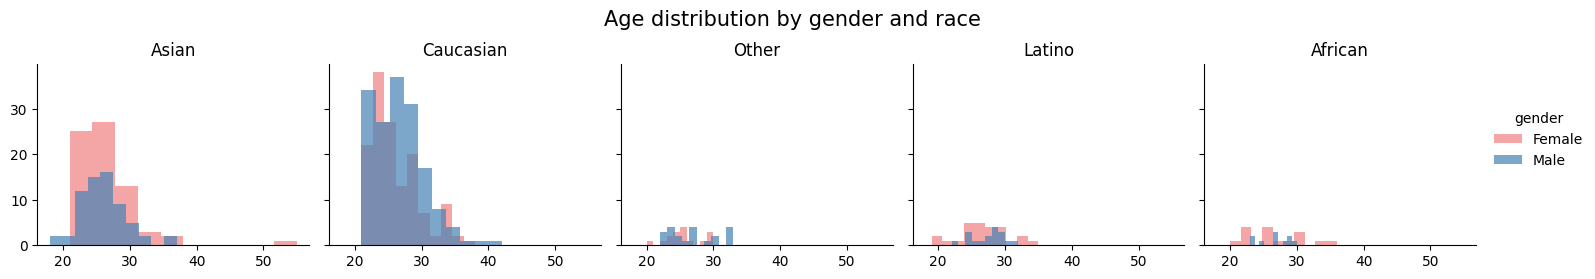

In [ ]:
ax = sns.FacetGrid(df_participants, col="race", hue="gender", palette=PALETTE)

ax.map(plt.hist, "age", alpha=0.7, bins=10)

for i, title in enumerate(ax.col_names):
    ax.axes[0, i].set_title(title)

ax.set_xlabels("", fontsize=1)
plt.subplots_adjust(top=0.8)
ax.add_legend()
ax.figure.suptitle(
    "Distribution de l'âge par gendre et origine ethnique", fontsize=15
)
plt.show()

Les personnes d'origine asiatiques sont plus représentées par des femmes.

Les personnes d'origine caucasiennes sont plus représentées par des hommes.

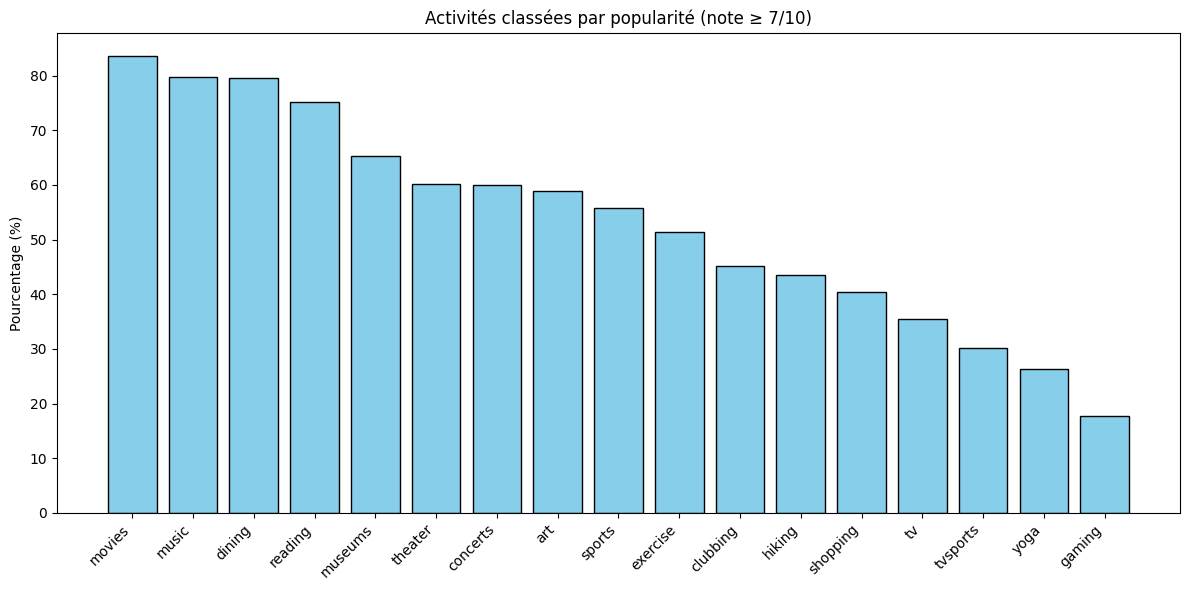

In [ ]:
# Centre d'intérêts des participants
def bar_percent_plot_sorted_1to10(cols, seuil=7):
    interest_data = {}

    for col in cols:
        series = df_participants[col]
        total = series.count()
        interested = series[series >= seuil].count()
        percent = (interested / total) * 100 if total > 0 else 0
        interest_data[col] = percent

    # Tri décroissant
    sorted_interests = dict(
        sorted(interest_data.items(), key=lambda item: item[1], reverse=True)
    )

    # Affichage
    plt.figure(figsize=(12, 6))
    plt.bar(
        sorted_interests.keys(),
        sorted_interests.values(),
        color="skyblue",
        edgecolor="black",
    )
    plt.ylabel("Pourcentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Activités classées par popularité (note ≥ {seuil}/10)")
    plt.tight_layout()
    plt.show()


interests = [
    "sports",
    "tvsports",
    "exercise",
    "dining",
    "museums",
    "art",
    "hiking",
    "gaming",
    "clubbing",
    "reading",
    "tv",
    "theater",
    "movies",
    "concerts",
    "music",
    "shopping",
    "yoga",
]

bar_percent_plot_sorted_1to10(interests, seuil=7)

Les 3 activités les plus populaires (note minimum de 7/10) chez les participants
- films, musique et dîner
--> activités cohérentes avec une population jeune

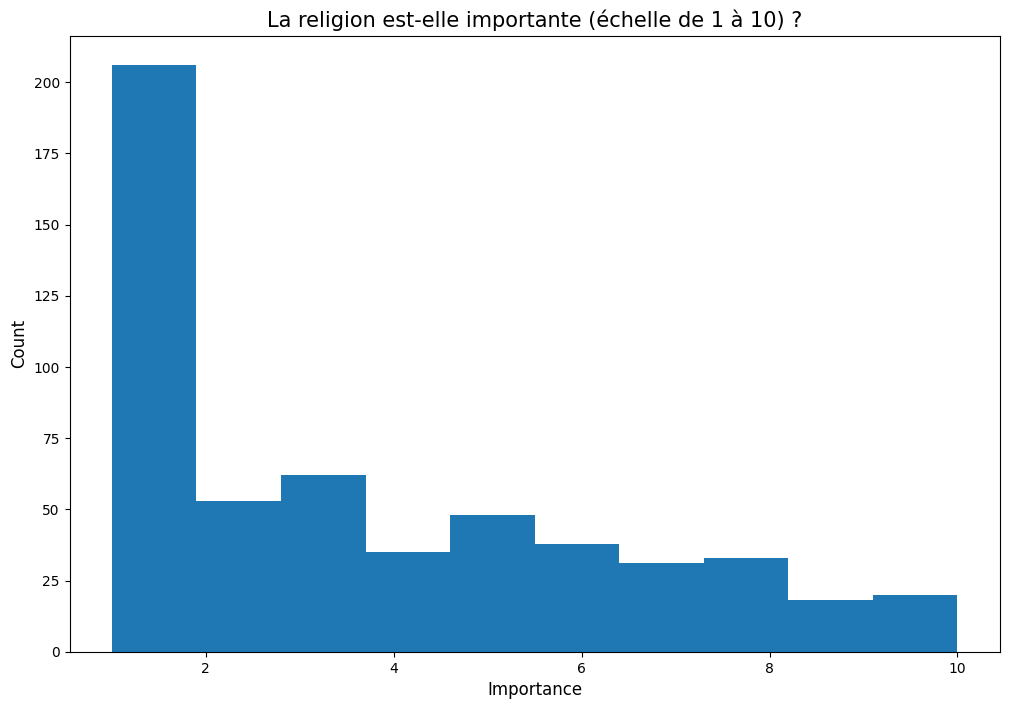

In [94]:
# Importance de la religion chez les participants
ax = df_participants.imprelig.hist(bins=10, figsize=(12, 8))
ax.set_title(
    "La religion est-elle importante (échelle de 1 à 10) ?", fontsize=15
)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(False)

In [80]:
# Importance de la religion, par genre
df_participants[["gender", "imprelig"]].groupby(["gender"]).agg(
    ["mean", "median", "min", "max", "count"]
).round(2)

imprelig                        
           mean median  min   max count
gender                                 
Female     4.14    3.0  1.0  10.0   269
Male       3.03    2.0  1.0  10.0   275

Importance de la religion : 
- pour 50% des participants, la religion n'est pas importante dans le choix d'un date (note de 1 à 3/10)
- La question de la religion est un critère plus marquée chez les femmes (4.14/10) que chez les hommes (3.03/10)

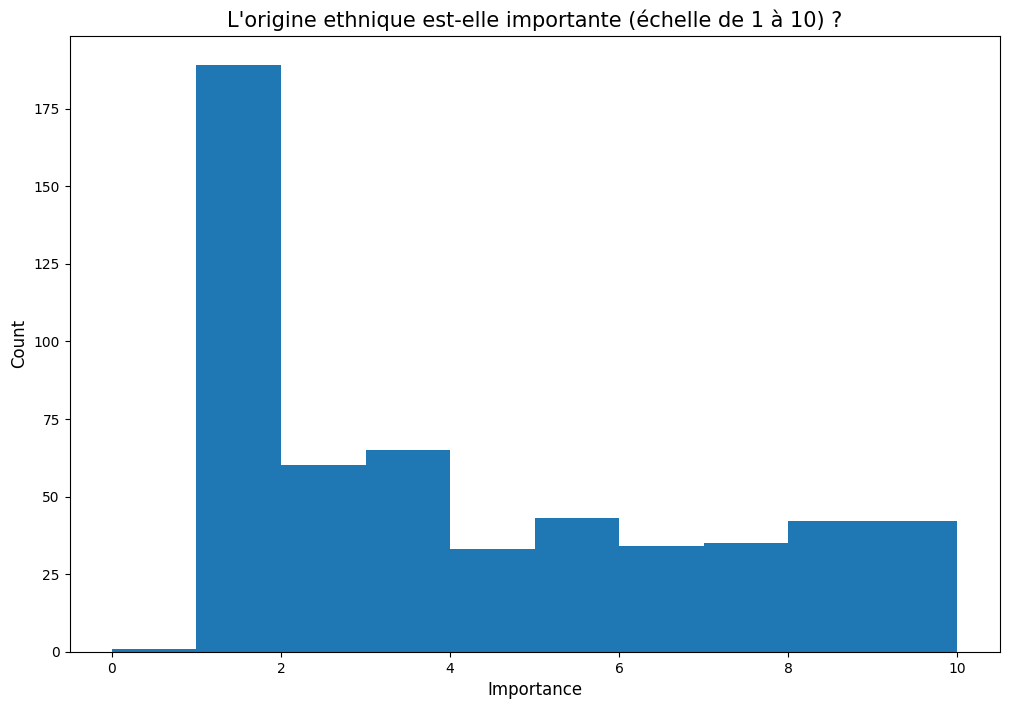

In [95]:
# Importance de l'origine ethnique chez les participants
ax = df_participants.imprace.hist(bins=10, figsize=(12, 8))
ax.set_title(
    "L'origine ethnique est-elle importante (échelle de 1 à 10) ?", fontsize=15
)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(False)

In [82]:
df_participants[["gender", "imprace"]].groupby(["gender"]).agg(
    ["mean", "median", "min", "max", "count"]
).round(2)

imprace                        
          mean median  min   max count
gender                                
Female    4.12    3.0  0.0  10.0   269
Male      3.36    3.0  1.0  10.0   275

Importance de la religion : 
- pour près de 50% des participants, la religion n'est pas importante dans le choix d'un date (note de 1 à 3/10)
- La question de la religion est un critère plus marquée chez les femmes (4.12/10) que chez les hommes (3.36/10)

In [ ]:
# Objectif recherché des participants en allant à des "date"
df_participants["goal"] = df_participants.goal.map(
    {
        1: "Seemed like a fun night out",
        2: "To meet new people",
        3: "To get a date",
        4: "Looking for a serious relationship",
        5: "To say I did it",
        6: "Other",
    }
).fillna(df_participants.goal)

df_participants.goal.value_counts(normalize=True).mul(100).round(2)

goal
Seemed like a fun night out           41.91
To meet new people                    34.74
To get a date                          7.35
To say I did it                        6.43
Other                                  5.51
Looking for a serious relationship     4.04
Name: proportion, dtype: float64

Objectifs recherché des participants :
- Les participants recherchent d'abord un lien social : 'Cela semblait être une soirée amusante' pour 42% des participants, 'Rencontrer des nouvelles personnes' pour 35%
- 11% des participants se déplacent à ce genre d'évènement pour rencontrer quelqu'un ou parce qu'ils recherchent une relation sérieuse

In [ ]:
# Fréquence de participations à des "date"
df_participants["date"] = df_participants.date.map(
    {
        1: "Several times a week",
        2: "Twice a week",
        3: "Once a week",
        4: "Twice a month",
        5: "Once a month",
        6: "Several times a year",
        7: "Almost never",
    }
).fillna(df_participants.date)

df_participants.date.value_counts(normalize=True).mul(100).round(2)

date
Several times a year    25.05
Twice a month           24.13
Once a month            18.23
Almost never            17.31
Once a week              9.94
Twice a week             4.05
Several times a week     1.29
Name: proportion, dtype: float64

Près d'1/4 des participants se rend à ce genre d'évènement deux fois par mois (24%)

In [98]:
# Fréquence des participants à sortir
df_participants["go_out"] = df_participants.go_out.map(
    {
        1: "Several times a week",
        2: "Twice a week",
        3: "Once a week",
        4: "Twice a month",
        5: "Once a month",
        6: "Several times a year",
        7: "Almost never",
    }
).fillna(df_participants.go_out)

df_participants.go_out.value_counts(normalize=True).mul(100).round(2)

go_out
Twice a week            35.11
Several times a week    32.54
Once a week             23.35
Twice a month            5.33
Once a month             2.21
Several times a year     1.10
Almost never             0.37
Name: proportion, dtype: float64

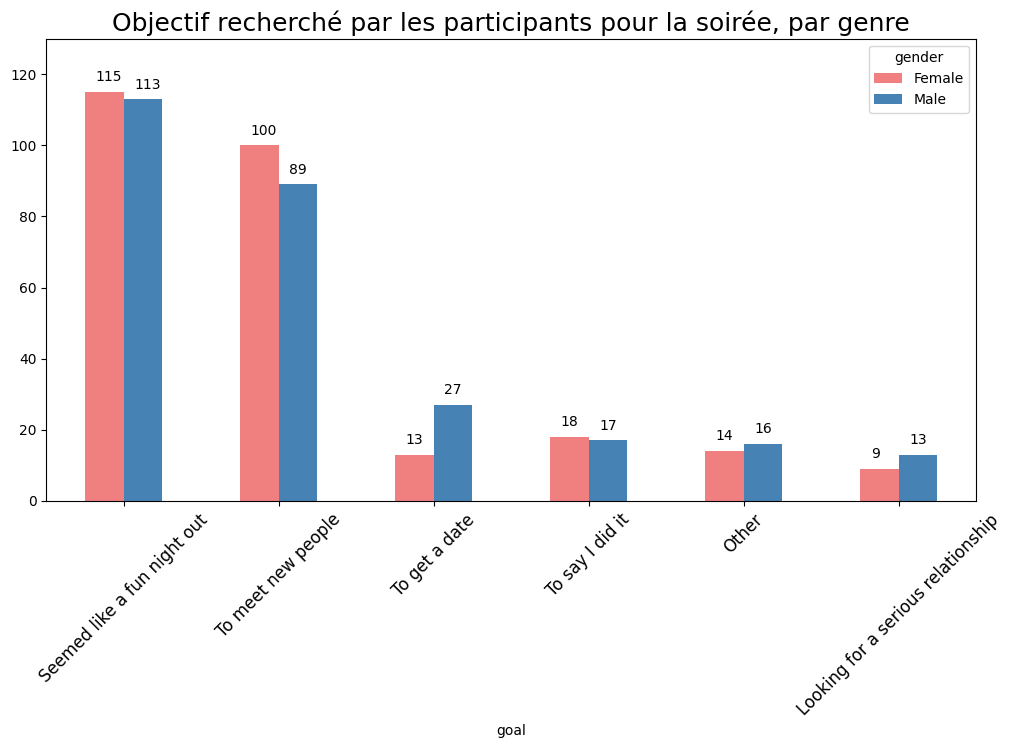

In [100]:
# Objectifs recherchés par les participants par genre
goal_by_gender = (
    df_participants[["gender", "goal"]]
    .groupby(["goal", "gender"])
    .size()
    .unstack()
)
goal_by_gender["Total"] = goal_by_gender.sum(axis=1)
goal_by_gender = goal_by_gender.sort_values("Total", ascending=False).drop(
    columns="Total"
)

ax = goal_by_gender.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 130),
    color=["lightcoral", "steelblue"],
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45)

ax.set_title(
    "Objectif recherché par les participants pour la soirée, par genre",
    fontsize=18,
)

# Légende au-dessus des barres
for i in ax.patches:
    ax.text(
        i.get_x() + 0.07,
        i.get_height() + 3,
        str(round((i.get_height()), 1)),
        fontsize=10,
    )

Pas de différence significative par genre dans l'objectif recherché en allant à de type d'évènements

Principaux enseignements :
- Notoriété de ce type d'applications aupprès des 25-30 ans, autant chez les hommes que chez les femmes.
- L'origine ethnique et la religion n'a pas d'importance (note entre 1 et 3/10) pour 1 participant sur 2.
- Ce type de population est d'abord à la recherche de "faire des rencontres" plutôt que de "rencontrer quelqu'un", ce qui peut expliquer le faible taux de date (15%).

## **4. Facteurs de décision des participants**

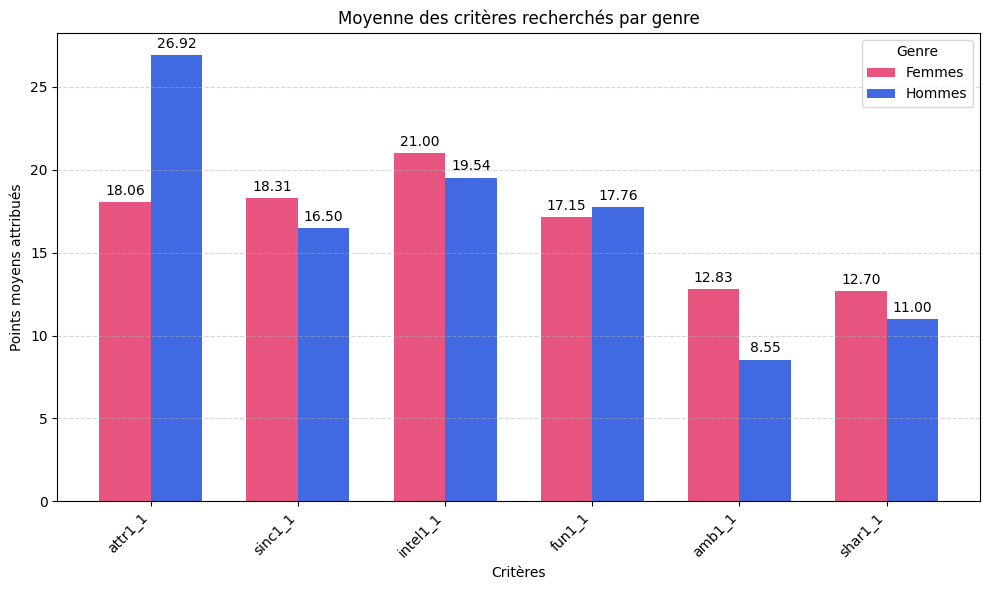

In [87]:
# Préférences initiales des participants par genre
prefs_cols = ["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]
prefs_by_gender = df.groupby("gender")[prefs_cols].mean().T

# Préparation des données pour le graphique
prefs_by_gender_plot = df.groupby("gender")[prefs_cols].mean().T.reset_index()
prefs_by_gender_plot.columns = ["Critère", "Femmes", "Hommes"]

# Données
labels = prefs_by_gender_plot["Critère"]
femmes = prefs_by_gender_plot["Femmes"]
hommes = prefs_by_gender_plot["Hommes"]

x = np.arange(len(labels))  # Position des critères sur l'axe X
width = 0.35  # Largeur des barres

fig, ax = plt.subplots(figsize=(10, 6))

# Barres
bar1 = ax.bar(x - width / 2, femmes, width, label="Femmes", color="#E75480")
bar2 = ax.bar(x + width / 2, hommes, width, label="Hommes", color="#4169E1")

# Ajout des valeurs au-dessus des barres
ax.bar_label(bar1, padding=3, fmt="%.2f")
ax.bar_label(bar2, padding=3, fmt="%.2f")

# Titre et axes
ax.set_ylabel("Points moyens attribués")
ax.set_xlabel("Critères")
ax.set_title("Moyenne des critères recherchés par genre")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend(title="Genre")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Ches les hommes,
* critère recherché 1: attractivité (26.92/100)
* critère rehcerché 2 : intelligence (19.54/100)
* critère recherché 3 : fun (17.76/100)

Chez les femmes, 
* critère recherché 1: intelligence (19.54/100)
* critère rehcerché 2 : sincérité (16.50/100)
* critère recherché 3 : attractivité (18.06/100)

Les hommes semblent afficher un attrait plus marqué pour l'apparence physique que les femmes.
Les attributs les moins désirables autant pour les hommes que pour les femmes sont l'ambition et l'intérêt commune pour les loisirs.

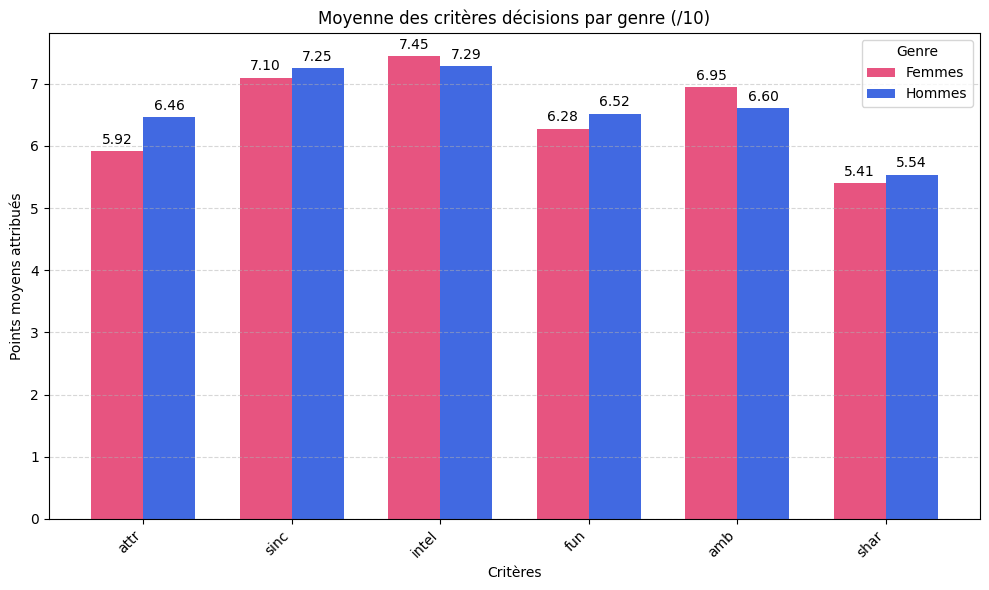

In [88]:
# Décisions initiales des participants par genre
dec_cols = ["attr", "sinc", "intel", "fun", "amb", "shar"]
dec_by_gender = df.groupby("gender")[dec_cols].mean().T

# Préparation des données pour le graphique
dec_by_gender_plot = df.groupby("gender")[dec_cols].mean().T.reset_index()
dec_by_gender_plot.columns = ["Critère", "Femmes", "Hommes"]

# Données
labels = dec_by_gender_plot["Critère"]
femmes = dec_by_gender_plot["Femmes"]
hommes = dec_by_gender_plot["Hommes"]

x = np.arange(len(labels))  # Position des critères sur l'axe X
width = 0.35  # Largeur des barres

fig, ax = plt.subplots(figsize=(10, 6))

# Barres
bar1 = ax.bar(x - width / 2, femmes, width, label="Femmes", color="#E75480")
bar2 = ax.bar(x + width / 2, hommes, width, label="Hommes", color="#4169E1")

# Ajout des valeurs au-dessus des barres
ax.bar_label(bar1, padding=3, fmt="%.2f")
ax.bar_label(bar2, padding=3, fmt="%.2f")

# Titre et axes
ax.set_ylabel("Points moyens attribués")
ax.set_xlabel("Critères")
ax.set_title("Moyenne des critères décisions par genre (/10)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend(title="Genre")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Ches les hommes,
* critère décision 1: intelligence (7.29/10)
* critère décision 2 : sincérité (7.25/10)
* critère décision 3 : ambition (6.60/10)

Chez les femmes, 
* critère décision 1: intelligence (7.45/10)
* critère décision 2 : sincérité (7.10/10)
* critère décision 3 : ambition (6.95/10)

Les notes moyennes attribuées à l'issue du speed dating se rejoignent que les participants soit un homme ou une femme.
Pour autant, cela ne permet pas de définir si certains attributs poussent plus que d'autres à aller vers un second date.

Corrélations entre les attributs et la décision en % (yes):

like     51.35
attr     48.68
fun      41.45
shar     40.06
prob     31.09
intel    21.73
sinc     21.00
amb      18.37
Name: dec, dtype: float64


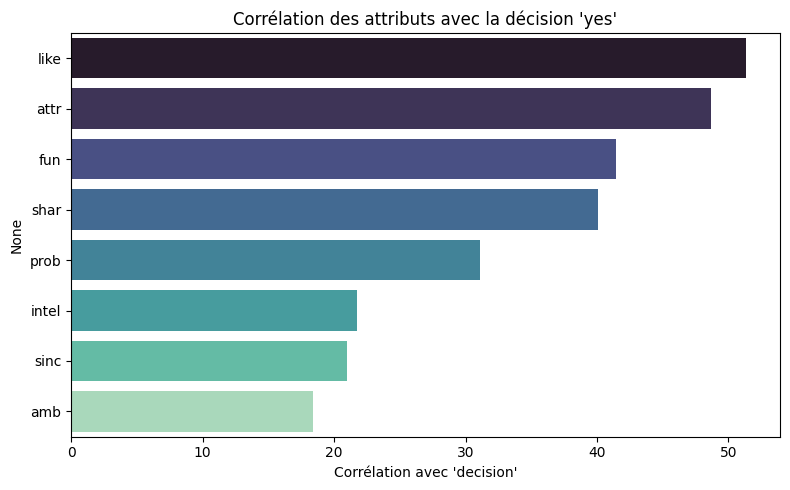

In [103]:
# Attributs évalués
attributs = ["attr", "sinc", "intel", "fun", "amb", "shar", "like", "prob"]

# Corrélation de chaque attribut avec la décision (dec = 0 ou 1)
correlations = df[attributs + ["dec"]].corr()["dec"].drop("dec")

# Trier par influence décroissante (%)
correlations = correlations.sort_values(ascending=False).mul(100).round(2)

# Affichage
print("Corrélations entre les attributs et la décision en % (yes):\n")
print(correlations)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    palette="mako",
    legend=False,
)

plt.title("Corrélation des attributs avec la décision 'yes'")
plt.xlabel("Corrélation avec 'decision'")
plt.tight_layout()
plt.show()

Plus le participant indique qu'il apprécie a apprécié la personne plus la probabilité est élevée pour qu'il valide son date.

Attraits qui poussent à valider un match :
1. Attractivité
2. Fun
3. Shared interested/Hobbies

Ces attributs diffèrent de ce que les participants indiquent comme étant des critères recherchés.

<Figure size 1000x600 with 0 Axes>

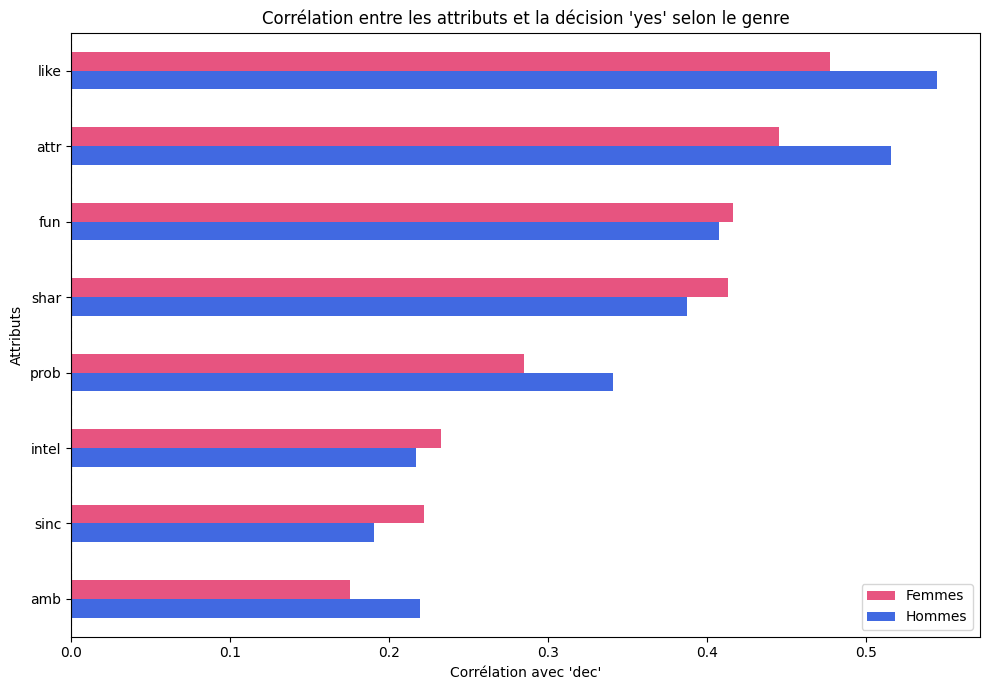

In [104]:
# Séparation des genres
df_f = df[df["gender"] == 0]
df_m = df[df["gender"] == 1]

# Corrélations avec la décision (par genre)
corr_f = df_f[attributs + ["dec"]].corr()["dec"].drop("dec")
corr_m = df_m[attributs + ["dec"]].corr()["dec"].drop("dec")

corr_df = pd.DataFrame({"Femmes": corr_f, "Hommes": corr_m})

# Tri des attributs selon la moyenne des deux
corr_df["Moyenne"] = corr_df.mean(axis=1)
corr_df = corr_df.sort_values(by="Moyenne", ascending=False)

plt.figure(figsize=(10, 6))
corr_df[["Femmes", "Hommes"]].plot(
    kind="barh", figsize=(10, 7), color=["#E75480", "#4169E1"]
)
plt.axvline(0, color="gray", linestyle="--")
plt.title(
    "Corrélation entre les attributs et la décision 'yes' selon le genre"
)
plt.xlabel("Corrélation avec 'dec'")
plt.ylabel("Attributs")
plt.gca().invert_yaxis()  # Pour que le plus fort soit en haut
plt.tight_layout()
plt.show()

Critères de décisions 'Yes' pour les hommes :
1. Attractivité
2. Fun
3. Shares Hobbies

Critères de décisions 'Yes' pour les Femmes :
1. Attractivité
2. Fun
3. Shares Hobbies

L'humour et l'attractivité semblent aller de pair. L'intérêt pour des activités communes semble également un point important dans la prise de décision.

In [108]:
# Corrélation avec la décision
correlations = df[attributs + ["dec"]].corr()["dec"].drop("dec")

# Trier du plus négatif au plus positif (%)
correlations_sorted = (
    correlations.sort_values(ascending=False).mul(100).round(2)
)
print("Corrélations les plus négatives (liées au 'no'):\n")
print(correlations_sorted.head())

Corrélations les plus négatives (liées au 'no'):

like    51.35
attr    48.68
fun     41.45
shar    40.06
prob    31.09
Name: dec, dtype: float64


Ce qui pousse à dire 'non' :
- plus la personne est parçue comme ambitieuse, moins elle reçoit de 'yes'
- plus la personne est parçue comme peu sincère, moins elle reçoit de 'yes'
- l'intelligence n'est pas un critère désicif dans l'attribution du 'yes'

Des critères qui sont valorisés socialement ne sont pas décisifs pour valider un date.
Rappelons que les participants sont d'abord présents car ils recherchent un lien social et sont là pour 's'amuser'

## **5.Conclusion**
* pas une science exacte !
* certains facteurs pourraient sembler plus déterminant que d'autre.
* garder en tête que les participants recherchent du lien social avant de trouver un date !

Aller plus loin
* Régression logisitique pour dire 'OUI'